In [1]:
import os
os.getcwd()


'c:\\Users\\esrao\\OneDrive\\Masaüstü\\Kaggle'

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
import pandas as pd

In [ ]:
#Load the datasets
customers = pd.read_excel("OLIST_DATA_SET/olist_customers_dataset.xlsx")
orders = pd.read_excel("OLIST_DATA_SET/olist_orders_dataset.xlsx")
order_items = pd.read_excel("OLIST_DATA_SET/olist_order_items_dataset.xlsx")
payments = pd.read_excel("OLIST_DATA_SET/olist_order_payments_dataset.xlsx")
reviews = pd.read_excel("OLIST_DATA_SET/olist_order_reviews_dataset.xlsx")
products = pd.read_excel("OLIST_DATA_SET/olist_products_dataset.xlsx")
sellers = pd.read_excel("OLIST_DATA_SET/olist_sellers_dataset.xlsx")
categories = pd.read_excel("OLIST_DATA_SET/product_category_name_translation.xlsx")



In [ ]:
# Initial Data Profiling – Dataset Size Overview
# This step checks the number of rows and columns in each table
# to understand dataset scale and table structure.
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)
print("Products:", products.shape)
print("Sellers:", sellers.shape)
print("Categories:", categories.shape)


Customers: (99441, 5)
Orders: (99441, 8)
Order Items: (112650, 7)
Payments: (103886, 5)
Reviews: (99224, 7)
Products: (32951, 9)
Sellers: (3095, 4)
Categories: (71, 2)


In [ ]:
#Previewing the Orders Dataset
orders.head()
orders.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [8]:
order_items.head()
order_items.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


In [9]:
payments.head()


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [ ]:
#Compare the number of unique order_ids in
order_items["order_id"].nunique()


98666

In [ ]:
#Compare the number of unique order_ids in
orders["order_id"].nunique()

99441

In [ ]:
#Orders that do not appear in order_items
missing_orders = set(orders["order_id"]) - set(order_items["order_id"])
len(missing_orders)


775

In [ ]:
# Calculate delivery duration in days to analyze shipping performance
orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.days

orders["delivery_days"].describe()


count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

In [ ]:
#Long Delivery Durations
orders.sort_values("delivery_days", ascending=False)[
    ["order_id", "order_status", "delivery_days"]
].head(20)


,order_id,order_status,delivery_days
19590,ca07593549f1816d26a572e06dc1eab6,delivered,209.0
55619,1b3190b2dfa9d789e1f14c05b647a14a,delivered,208.0
61610,440d0d17af552815d15a9e41abe49359,delivered,195.0
70307,2fb597c2f772eca01b1f5c561bf6cc7b,delivered,194.0
38509,0f4519c5f1c541ddec9f21b3bddd533a,delivered,194.0
89130,285ab9426d6982034523a855f55a885e,delivered,194.0
11399,47b40429ed8cce3aee9199792275433f,delivered,191.0
81401,2fe324febf907e3ea3f2aa9650869fa5,delivered,189.0
54480,2d7561026d542c8dbd8f0daeadf67a43,delivered,188.0
68769,c27815f7e3dd0b926b58552628481575,delivered,187.0


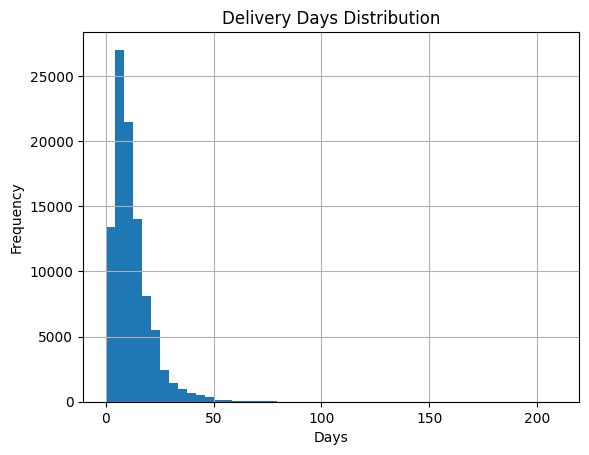

In [ ]:
#Visualise the distrubution of delivery days
import matplotlib.pyplot as plt

orders["delivery_days"].hist(bins=50)
plt.title("Delivery Days Distribution")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show()


In [ ]:
#Identify orders with exceptionally long delivery times
orders[orders["delivery_days"] > 60].shape


(288, 9)

In [ ]:
#Calculate the percentage of late deliveries based on estimated delivery dates
orders["late_delivery"] = (
    orders["order_delivered_customer_date"]
    > orders["order_estimated_delivery_date"]
).astype(int)

orders["late_delivery"].mean()


np.float64(0.07870998883760219)

In [ ]:
#
orders["order_delivered_customer_date"] > orders["order_estimated_delivery_date"]
(orders["order_delivered_customer_date"] > 
 orders["order_estimated_delivery_date"]).sum()


np.int64(7827)

In [20]:
delivered_orders = orders[orders["order_status"] == "delivered"]

total_delivered = delivered_orders.shape[0]
total_delivered


96478

In [ ]:
#Calculate the number of date deliveries that were late
late_count = (
    delivered_orders["order_delivered_customer_date"] >
    delivered_orders["order_estimated_delivery_date"]
).sum()

late_rate = late_count / total_delivered * 100

round(late_rate, 2)


np.float64(8.11)

In [ ]:
#Merge delivered orders with reviews and compare average review scores for late vs on-time deliveries

orders_reviews = delivered_orders.merge(
    reviews[["order_id", "review_score"]],
    on="order_id",
    how="left"
)

orders_reviews.groupby(
    delivered_orders["order_delivered_customer_date"] >
    delivered_orders["order_estimated_delivery_date"]
)["review_score"].mean()


False    4.154398
True     4.152913
Name: review_score, dtype: float64

In [ ]:
#Create a binary column for late delivery and analyse its impact on review scores
orders_reviews["late_delivery"] = (
    orders_reviews["order_delivered_customer_date"] >
    orders_reviews["order_estimated_delivery_date"]
).astype(int)

orders_reviews.groupby("late_delivery")["review_score"].mean()


late_delivery
0    4.293737
1    2.566494
Name: review_score, dtype: float64

In [ ]:
#Analyse the late delivery rate by seller
seller_delivery = order_items.merge(
    orders[["order_id", "late_delivery"]],
    on="order_id",
    how="left"
)

seller_late_rate = seller_delivery.groupby("seller_id")["late_delivery"].mean()

seller_late_rate.sort_values(ascending=False).head(10)


seller_id
535bf14f36346c7f59d87cece104d70c    1.0
bc8c8d665ec4664d286be0d521722b19    1.0
be1e9e378700cecaa4ebf71433d7915c    1.0
2a50b7ee5aebecc6fd0ff9784a4747d6    1.0
2a73cba571d90c694b7caca072ccf6ce    1.0
f524ad65d7e0f1daab730ef2d2e86196    1.0
c13ef0cfbe42f190780f621ce81f2234    1.0
6524b847b982cd56bb5d4b02b776ee42    1.0
c611f4ce9ce875bcc063fa97fd4d7d12    1.0
344223b2a90784f64136a8a5da012e7f    1.0
Name: late_delivery, dtype: float64

In [ ]:
#check for missing values in delivery dates
orders["order_delivered_customer_date"].isnull().sum()


np.int64(2965)

In [ ]:
#identify orders with missing delivery dates and their statuses
missing_delivery = orders[orders["order_delivered_customer_date"].isnull()]

missing_delivery["order_status"].value_counts()


order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

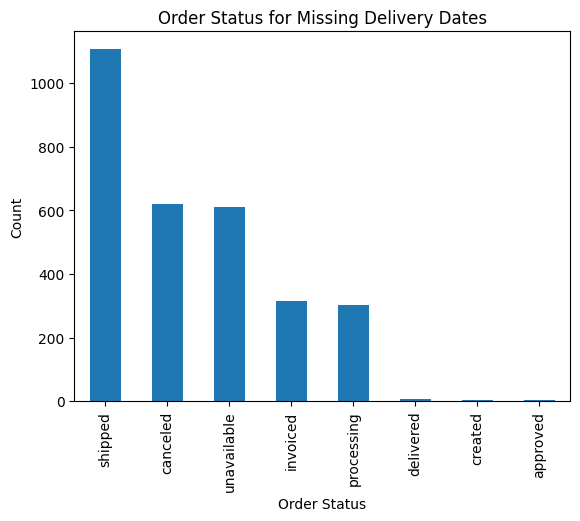

In [ ]:
#Order statuses for orders with missing delivery dates
status_counts = missing_delivery["order_status"].value_counts()

status_counts.plot(kind="bar")
plt.title("Order Status for Missing Delivery Dates")
plt.xlabel("Order Status")
plt.ylabel("Count")
plt.show()


In [28]:
orders[
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_customer_date"].isnull())
].shape


(8, 10)

In [ ]:
#identify orders with missing delivery dates and their statuses
orders[
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_customer_date"].isnull())
]


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,late_delivery
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaT,2017-12-18,NaN,0
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaT,2018-07-16,NaN,0
43834,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaT,2018-07-30,NaN,0
79263,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaT,2018-07-30,NaN,0
82868,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaT,2018-07-24,NaN,0
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaT,NaT,2017-06-23,NaN,0
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaT,2018-06-26,NaN,0
98038,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaT,2018-07-19,NaN,0


In [30]:
orders = orders[
    ~(
        (orders["order_status"] == "delivered") &
        (orders["order_delivered_customer_date"].isnull())
    )
]


In [31]:
orders[
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_customer_date"].isnull())
].shape


(0, 10)

In [32]:
orders.shape


(99433, 10)